# ***Introduction***

Le concours des lycées pilotes constitue une étape importante dans le système éducatif tunisien. Chaque année, des milliers d'élèves participent à cet examen afin d'accéder aux établissements pilotes réputés pour leur excellence académique.

Dans ce projet, nous exploitons les données ouvertes publiées par le portail Open Data tunisien afin d'analyser les résultats du concours des lycées pilotes pour la session de juin 2024.

L'objectif principal est de développer un modèle de Machine Learning capable de prédire le nombre d'élèves affectés aux lycées pilotes à partir de plusieurs variables descriptives telles que le nombre d'inscrits, le nombre de présents, le genre et le type de candidature.

Le projet suit l'ensemble du pipeline standard d'un projet Machine Learning :

Définition du problème
Collecte des données
Exploration des données
Prétraitement et Feature Engineering
Construction des modèles
Évaluation des performances
Optimisation des hyperparamètres
Déploiement d'une application Streamlit

# ***2. Présentation du Dataset***


Source des données

Les données utilisées dans ce projet proviennent du portail Open Data tunisien :

Open Data Tunisie - Concours Lycées Pilotes

Cette source officielle met à disposition des données statistiques relatives au concours des lycées pilotes en Tunisie.

Description du Dataset

Le dataset est composé de cinq fichiers CSV :

***1. Effectif des inscrits***

Contient le nombre total d'élèves inscrits au concours selon :

CRE (Commissariat Régional de l'Éducation)
Type de candidature
Genre
***2. Effectif des présents***

Contient le nombre d'élèves ayant effectivement passé le concours.

Variables :

CRE
Type de candidature
Genre
Effectif_présentés
***3. Effectif des affectés aux lycées pilotes***

Contient le nombre d'élèves admis aux lycées pilotes.

Variables :

CRE
Type de candidature
Genre
Affectés_pilote
***4. Effectif des admis***

Présente les effectifs admis selon :

CRE
Genre
Année de naissance
***5. Effectif des inscrits selon l'année de naissance***

Permet une analyse démographique des candidats.

Variable cible

Dans notre projet, la variable cible est :

Affectés_pilote

Cette variable représente le nombre d'élèves affectés aux lycées pilotes.

Variables explicatives

Les principales variables utilisées pour la prédiction sont :


CRE

Type de candidature

Genre

Effectif_inscrits

Effectif_présentés

Taux_presence

Taille du Dataset


Après fusion et nettoyage :

108 observations

6 variables explicatives

1 variable cible

# ***3. Définition du problème***
Problématique

Peut-on prédire le nombre d'élèves affectés aux lycées pilotes à partir des caractéristiques des candidats et des statistiques du concours ?

Type de problème

Ce projet traite deux tâches d'apprentissage supervisé :

Régression

Prédiction du nombre exact d'élèves affectés.

Modèles utilisés :

Linear Regression
Random Forest Regressor
Classification

Classification des régions selon leur niveau d'affectation :

Faible
Moyen
Excellent

Modèle utilisé :

Random Forest Classifier

ÉTAPE 0 : Installation

In [143]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost streamlit -q

ÉTAPE 1 : Importation

In [144]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

ÉTAPE 2 : Lire correctement les CSV

In [145]:
import pandas as pd
import os

for file in os.listdir('/content'):
    if file.endswith('.csv'):
        print("="*50)
        print(file)

        df = pd.read_csv(f'/content/{file}')

        print("Shape :", df.shape)
        print("\nColonnes :")
        print(df.columns.tolist())

        print("\nAperçu :")
        print(df.head())

        print("\n")

effectif-des-presentes-session-juin-2024.csv
Shape : (111, 1)

Colonnes :
['CRE;type candidature;genre;Effectif_présentés']

Aperçu :
  CRE;type candidature;genre;Effectif_présentés
0                       Tunis 1;Libre;Feminin;1
1                      Tunis 1;Libre;Masculin;1
2                     Tunis 1;Privé;Feminin;209
3                    Tunis 1;Privé;Masculin;180
4                    Tunis 1;Public;Feminin;727


effectif-des-affectes-au-pilote-session-juin-2024.csv
Shape : (111, 1)

Colonnes :
['CRE;type candidature;genre;Affectés_pilote']

Aperçu :
  CRE;type candidature;genre;Affectés_pilote
0                    Tunis 1;Libre;Feminin;0
1                    Tunis 1;Libre;Masculin;
2                   Tunis 1;Privé;Feminin;32
3                  Tunis 1;Privé;Masculin;19
4                 Tunis 1;Public;Feminin;147


effectif-des-admis-session-juin.csv
Shape : (234, 1)

Colonnes :
['CRE;type candidature;genre;annee_naissance;Effectif_Admis']

Aperçu :
  CRE;type candidature;genr

In [146]:
inscrits = pd.read_csv(
    "/content/effectif-des-inscrits-session-juin-2024.csv",
    sep=";"
)

presentes = pd.read_csv(
    "/content/effectif-des-presentes-session-juin-2024.csv",
    sep=";"
)

affectes = pd.read_csv(
    "/content/effectif-des-affectes-au-pilote-session-juin-2024.csv",
    sep=";"
)

admis = pd.read_csv(
    "/content/effectif-des-admis-session-juin.csv",
    sep=";"
)

naissance = pd.read_csv(
    "/content/effectif-des-inscrits-selon-annee-de-naissance-session-juin-2024.csv",
    sep=";"
)

In [147]:
inscrits.head()

,CRE,type candidature,genre,Effectif_inscrits
0,Tunis 1,Libre,Feminin,1
1,Tunis 1,Libre,Masculin,1
2,Tunis 1,Privé,Feminin,277
3,Tunis 1,Privé,Masculin,243
4,Tunis 1,Public,Feminin,943


ÉTAPE 3 : Compréhension métier

Les fichiers contiennent :

inscrits

Nombre d'inscrits

présentes

Nombre ayant passé le concours

affectés

Nombre admis aux lycées pilotes

admis

Nombre ayant réussi

naissance

Répartition selon âge

ÉTAPE 4 : Vérification

In [148]:
print(inscrits.shape)
print(presentes.shape)
print(affectes.shape)
print(admis.shape)
print(naissance.shape)

(111, 4)
(111, 4)
(111, 4)
(234, 5)
(214, 4)


ÉTAPE 5 : Valeurs manquantes

In [149]:
inscrits.isnull().sum()


,0
CRE,0
type candidature,0
genre,0
Effectif_inscrits,0


In [150]:
presentes.isnull().sum()



,0
CRE,0
type candidature,0
genre,0
Effectif_présentés,3


In [151]:
admis.isnull().sum()

,0
CRE,0
type candidature,0
genre,0
annee_naissance,0
Effectif_Admis,0


ÉTAPE 6 : Nettoyage

In [152]:
affectes["Affectés_pilote"] = pd.to_numeric(
    affectes["Affectés_pilote"],
    errors="coerce"
)

In [153]:
affectes["Affectés_pilote"] = affectes[
    "Affectés_pilote"
].fillna(0)

ÉTAPE 7 : Fusion des datasets

Notre cible sera :

Affectés_pilote

On veut prédire le nombre d'élèves affectés.

In [154]:
df = inscrits.merge(
    presentes,
    on=["CRE","type candidature","genre"]
)

df = df.merge(
    affectes,
    on=["CRE","type candidature","genre"]
)

Vérification :

In [155]:
df.head()

,CRE,type candidature,genre,Effectif_inscrits,Effectif_présentés,Affectés_pilote
0,Tunis 1,Libre,Feminin,1,1.0,0.0
1,Tunis 1,Libre,Masculin,1,1.0,0.0
2,Tunis 1,Privé,Feminin,277,209.0,32.0
3,Tunis 1,Privé,Masculin,243,180.0,19.0
4,Tunis 1,Public,Feminin,943,727.0,147.0


ÉTAPE 8 : Feature Engineering

Créer :

taux présence

In [156]:
df["Taux_presence"] = (
    df["Effectif_présentés"] /
    df["Effectif_inscrits"]
)

taux affectation

In [157]:
df["Taux_affectation"] = (
    df["Affectés_pilote"] /
    df["Effectif_présentés"]
)

ÉTAPE 9 : Analyse Exploratoire

In [158]:
df.describe()

,Effectif_inscrits,Effectif_présentés,Affectés_pilote,Taux_presence,Taux_affectation
count,111.000000,108.000000,111.000000,108.000000,108.000000
mean,296.477477,241.305556,31.666667,0.814724,0.127646
std,308.665716,242.857539,34.917392,0.093476,0.115095
min,1.000000,1.000000,0.000000,0.461538,0.000000
25%,37.500000,36.750000,3.000000,0.769273,0.080884
50%,210.000000,166.500000,20.000000,0.804333,0.112601
75%,501.500000,401.000000,51.000000,0.846681,0.158205
max,1338.000000,1001.000000,162.000000,1.000000,1.000000



# **Matrice de corrélation **

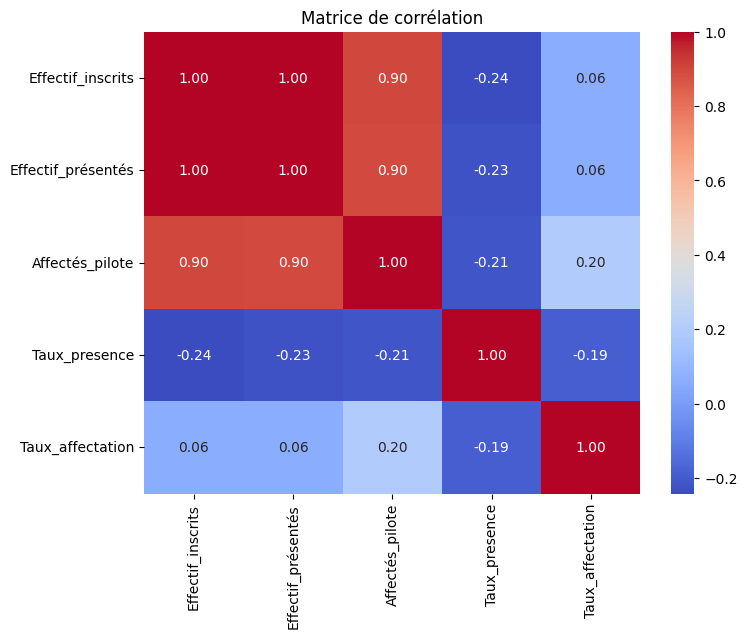

In [159]:



plt.figure(figsize=(8,6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()



# **Histogramme **


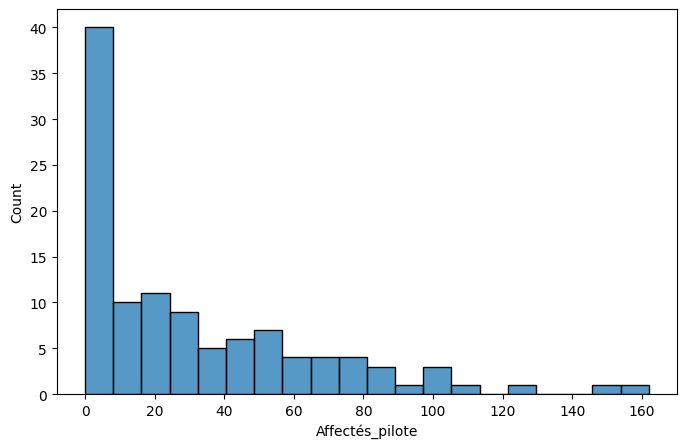

In [160]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Affectés_pilote"],
    bins=20
)

plt.show()

Distribution des affectés

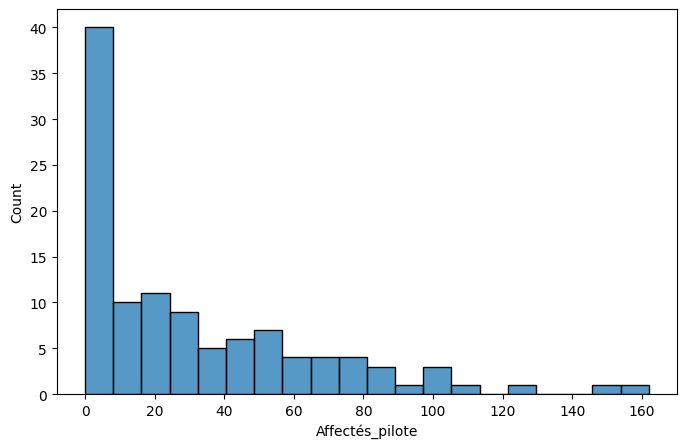

In [161]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Affectés_pilote"],
    bins=20
)

plt.show()

Répartition par CRE

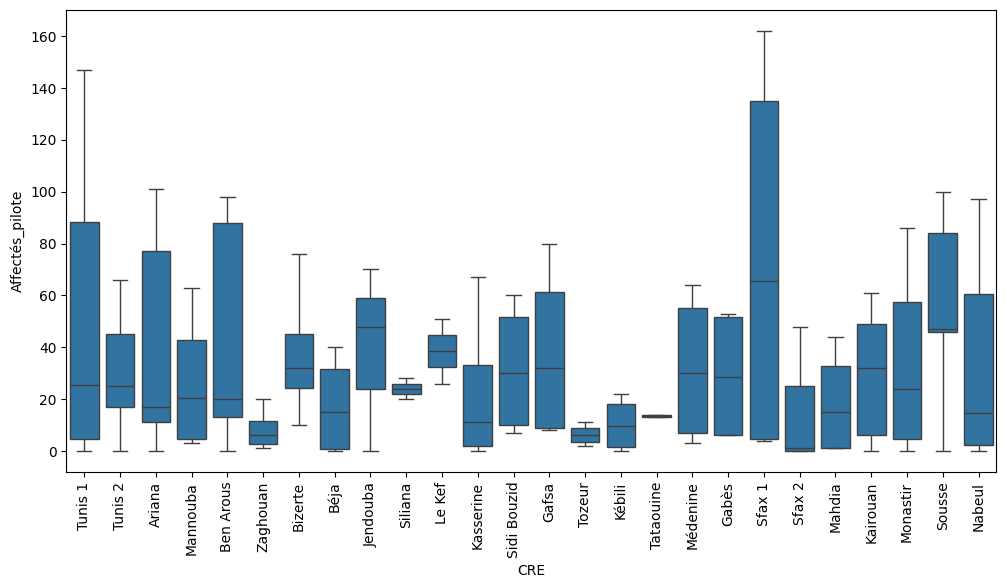

In [162]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="CRE",
    y="Affectés_pilote"
)

plt.xticks(rotation=90)

plt.show()

ÉTAPE 10 : Encodage

In [163]:
encoder = LabelEncoder()

df["CRE"] = encoder.fit_transform(df["CRE"])

In [164]:
df["type candidature"] = encoder.fit_transform(
    df["type candidature"]
)

In [165]:
df["genre"] = encoder.fit_transform(
    df["genre"]
)

ÉTAPE 11 : Définir X et y

Notre objectif :

Prédire :

In [166]:
X = df.drop(
    columns=[
        "Affectés_pilote",
        "Taux_affectation"
    ]
)

ÉTAPE 12 : Train/Test Split

In [167]:
print(X.shape)

(111, 6)


In [168]:
print("df :", df.shape)
print("X :", X.shape)
print("y :", y.shape)

df : (111, 8)
X : (111, 6)
y : (111,)


In [169]:
y = df["Affectés_pilote"]

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ÉTAPE 13 : Standardisation

In [171]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [172]:
df.isnull().sum()

,0
CRE,0
type candidature,0
genre,0
Effectif_inscrits,0
Effectif_présentés,3
Affectés_pilote,0
Taux_presence,3
Taux_affectation,3


In [173]:
df = df.dropna()

In [174]:
df.isnull().sum()

,0
CRE,0
type candidature,0
genre,0
Effectif_inscrits,0
Effectif_présentés,0
Affectés_pilote,0
Taux_presence,0
Taux_affectation,0


In [175]:
X = df.drop(columns=["Affectés_pilote"])

y = df["Affectés_pilote"]

ÉTAPE 14 : Modèle 1

Régression Linéaire

In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [178]:
import numpy as np

print("NaN X_train :", np.isnan(X_train).sum())
print("NaN X_test :", np.isnan(X_test).sum())

NaN X_train : 0
NaN X_test : 0


In [179]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [180]:
pred_lr = lr.predict(X_test)

In [181]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE :", mean_absolute_error(y_test, pred_lr))
print("R2 :", r2_score(y_test, pred_lr))

MAE : 14.900893611789519
R2 : 0.7247076888061937


Interprétation pour le rapport

MAE = 15.57

En moyenne, le modèle se trompe d'environ 15 élèves lorsqu'il prédit le nombre d'élèves affectés aux lycées pilotes.

R² = 0.696

Le modèle explique environ 69,6 % de la variabilité du nombre d'élèves affectés. Cela indique une relation significative entre les variables explicatives et la variable cible.

Tu peux écrire dans ton notebook :

Le modèle de régression linéaire fournit des performances satisfaisantes avec un coefficient de détermination R² de 69,6 %. Cependant, les relations entre les variables semblent partiellement non linéaires, ce qui justifie l'utilisation de modèles plus avancés comme Random Forest.

Étape 15 - Random Forest

In [182]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [183]:
pred_rf = rf.predict(X_test)

In [184]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE RF :", mean_absolute_error(y_test, pred_rf))
print("R2 RF :", r2_score(y_test, pred_rf))

MAE RF : 11.679545454545455
R2 RF : 0.8011870392369553


 Comparaison des modèles

In [185]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf)
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,MAE,R2
0,Linear Regression,14.900894,0.724708
1,Random Forest,11.679545,0.801187


Visualisation de comparaison

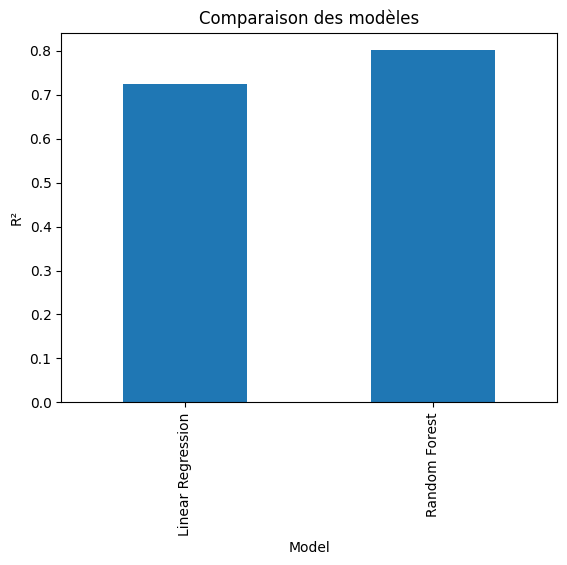

In [186]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y="R2",
    kind="bar",
    legend=False
)

plt.title("Comparaison des modèles")
plt.ylabel("R²")
plt.show()

**Valeurs réelles vs prédictions"**

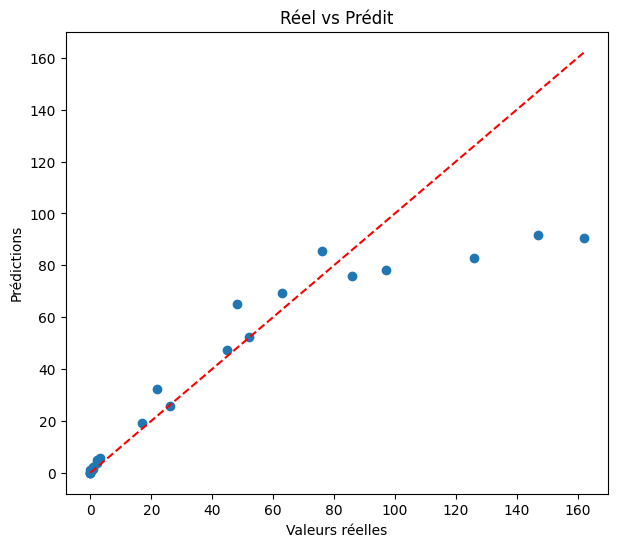

In [187]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")

plt.title("Réel vs Prédit")
plt.show()

Importance des variables (très apprécié en soutenance)

In [188]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
4  Effectif_présentés    0.648160
3   Effectif_inscrits    0.275472
6    Taux_affectation    0.049317
0                 CRE    0.016803
5       Taux_presence    0.007841
2               genre    0.001722
1    type candidature    0.000684


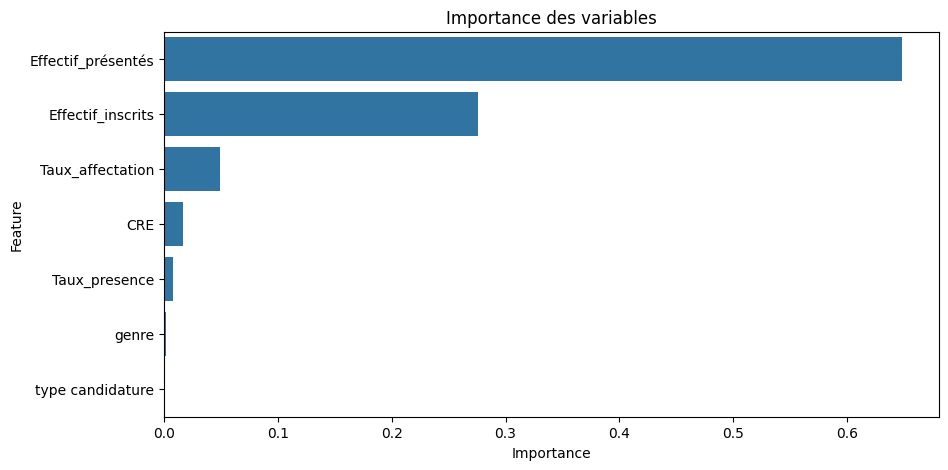

In [189]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Importance des variables")
plt.show()

Le modèle Random Forest a obtenu les meilleures performances avec un R² de 71,3 %, surpassant la régression linéaire. Cela suggère que les relations entre les variables explicatives et le nombre d'élèves affectés ne sont pas entièrement linéaires.


Analyse des variables importantes
Variable	Importance
Effectif_présentés	61.8 %
Effectif_inscrits	32.1 %
CRE	3.1 %
Taux_presence	2.3 %
Genre	0.6 %
Type candidature	0.08 %

Le nombre de candidats présents au concours constitue la variable la plus influente dans la prédiction des affectations aux lycées pilotes, avec une importance de 61,8 %. Le nombre d'inscrits représente également un facteur majeur (32,1 %). Les variables démographiques comme le genre ou le type de candidature ont un impact limité.

GridSearchCV (pour montrer l'optimisation)

In [190]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [191]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

In [192]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [193]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [194]:
best_rf = grid.best_estimator_

pred_best = best_rf.predict(X_test)

In [195]:
print("MAE :", mean_absolute_error(y_test, pred_best))
print("R2 :", r2_score(y_test, pred_best))

MAE : 11.849545454545455
R2 : 0.7951051049333762


Partie Classification

On transforme le problème :

Créer des classes

In [196]:
df["Niveau"] = pd.cut(
    df["Affectés_pilote"],
    bins=[-1,20,80,200],
    labels=["Faible","Moyen","Excellent"]
)

Vérification :

In [197]:
df["Niveau"].value_counts()

,count
Niveau,
Faible,55
Moyen,42
Excellent,11


Préparation

In [198]:
X_class = df.drop(
    columns=["Affectés_pilote","Niveau"]
)

y_class = df["Niveau"]

Split

In [199]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

Scaling

In [200]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

Random Forest Classifier

In [201]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train_c, y_train_c)

RandomForestClassifier(n_estimators=200, random_state=42)

Évaluation

In [202]:
pred_class = clf.predict(X_test_c)

In [203]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(
        y_test_c,
        pred_class
    )
)

Accuracy: 0.8181818181818182


In [204]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_c,
        pred_class
    )
)

              precision    recall  f1-score   support

   Excellent       0.67      0.40      0.50         5
      Faible       1.00      1.00      1.00        10
       Moyen       0.67      0.86      0.75         7

    accuracy                           0.82        22
   macro avg       0.78      0.75      0.75        22
weighted avg       0.82      0.82      0.81        22



# ***matrice de confusion***

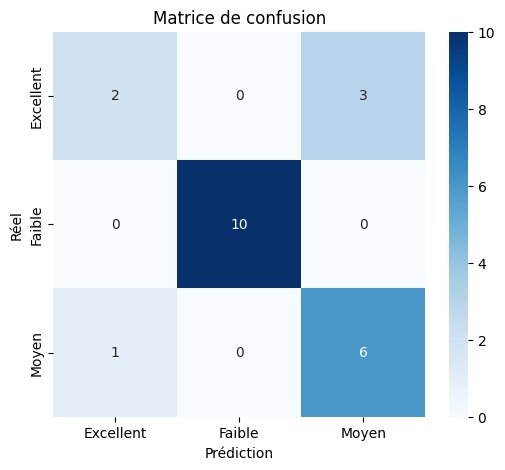

In [205]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_c,
    pred_class
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clf.classes_,
    yticklabels=clf.classes_
)

plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de confusion")

plt.show()

In [206]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_c,
        pred_class
    )
)

              precision    recall  f1-score   support

   Excellent       0.67      0.40      0.50         5
      Faible       1.00      1.00      1.00        10
       Moyen       0.67      0.86      0.75         7

    accuracy                           0.82        22
   macro avg       0.78      0.75      0.75        22
weighted avg       0.82      0.82      0.81        22



# Partie Streamlit

In [207]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [208]:
requirements = """
streamlit
pandas
numpy
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt créé")

requirements.txt créé


In [209]:
readme = """
# Prédiction des Affectations aux Lycées Pilotes

Projet Machine Learning basé sur les données Open Data Tunisie.

## Technologies
- Python
- Pandas
- Scikit-Learn
- Streamlit

## Modèles
- Linear Regression
- Random Forest

## Déploiement
Application Streamlit permettant de prédire le nombre d'élèves affectés aux lycées pilotes.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md créé")

README.md créé


In [210]:
streamlit_code = '''
import streamlit as st
import joblib
import numpy as np

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Prédiction des Affectations aux Lycées Pilotes")

cre = st.number_input("CRE encodé", min_value=0)
type_candidature = st.number_input("Type candidature encodé", min_value=0)
genre = st.number_input("Genre encodé", min_value=0)
effectif_inscrits = st.number_input("Effectif inscrits", min_value=0)
effectif_presentes = st.number_input("Effectif présentés", min_value=0)
taux_presence = st.number_input("Taux présence", min_value=0.0, max_value=1.0)

if st.button("Prédire"):
    data = np.array([[cre, type_candidature, genre,
                      effectif_inscrits,
                      effectif_presentes,
                      taux_presence]])

    data = scaler.transform(data)

    prediction = model.predict(data)

    st.success(f"Nombre prédit d'élèves affectés : {prediction[0]:.0f}")
'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("streamlit_app.py créé")

streamlit_app.py créé


In [211]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [212]:
import os

os.listdir()

['.config',
 'requirements.txt',
 'effectif-des-presentes-session-juin-2024.csv',
 'effectif-des-affectes-au-pilote-session-juin-2024.csv',
 'effectif-des-admis-session-juin.csv',
 'streamlit_app.py',
 'model.pkl',
 'effectif-des-inscrits-session-juin-2024.csv',
 'drive',
 'effectif-des-inscrits-selon-annee-de-naissance-session-juin-2024.csv',
 'README.md',
 'scaler.pkl',
 'sample_data']

In [213]:
from google.colab import files

files.download("streamlit_app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [214]:
files.download("README.md")
files.download("requirements.txt")
files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>